# LoHa + LoKr 交互教学

配套 lecture：[`../lectures/05-loha-lokr.md`](../lectures/05-loha-lokr.md)  
配套论文：[`../papers/05a-loha-2021.pdf`](../papers/05a-loha-2021.pdf) · [`../papers/05b-lokr-lycoris-2023.pdf`](../papers/05b-lokr-lycoris-2023.pdf)

本 notebook 演示：
1. LoHa: Hadamard 积 → 等效秩 r²
2. LoKr: Kronecker 积 → 极致参数压缩
3. 等效秩实测（matrix_rank）
4. 横向对比 LoRA / LoHa / LoKr
5. peft 兼容性说明

In [1]:
import sys
from pathlib import Path
import torch
import matplotlib.pyplot as plt

src_dir = (Path.cwd().parent / 'src').resolve()
sys.path.insert(0, str(src_dir))

from common import print_param_summary
from loha_minimal import LoHaGPT2, LoHaLinear
from lokr_minimal import LoKrGPT2, LoKrLinear

C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. LoHa: Hadamard 积

ΔW = (B_1 A_1) ⊙ (B_2 A_2)，等效秩 ≤ r²

In [2]:
torch.manual_seed(42)
loha = LoHaGPT2(r=8, alpha=16)
print_param_summary(loha, 'LoHa (r=8)')

layer0 = loha.lm.transformer.h[0].attn.c_attn
print(f'\n每对低秩因子: A_1/B_1 / A_2/B_2')
print(f'  A_1 shape: {tuple(layer0.A_1.shape)}, B_1 shape: {tuple(layer0.B_1.shape)}')
print(f'  A_2 shape: {tuple(layer0.A_2.shape)}, B_2 shape: {tuple(layer0.B_2.shape)}')
print(f'\n初始 B_1 全零 → ΔW = (0×A_1) ⊙ (B_2 A_2) = 0')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 19253.05it/s]

  LoHa (r=8)
  Total params:      125,029,632
  Trainable params:      589,824  (0.4717%)
  Frozen params:     124,439,808

每对低秩因子: A_1/B_1 / A_2/B_2
  A_1 shape: (8, 768), B_1 shape: (2304, 8)
  A_2 shape: (8, 768), B_2 shape: (2304, 8)

初始 B_1 全零 → ΔW = (0×A_1) ⊙ (B_2 A_2) = 0


## 2. 等效秩实测：Hadamard 让秩相乘

In [3]:
ranks = []
for r in [2, 4, 8, 16]:
    torch.manual_seed(42)
    model = LoHaGPT2(r=r, alpha=2*r)
    layer = model.lm.transformer.h[0].attn.c_attn
    with torch.no_grad():
        layer.B_1.normal_(std=0.1)
    delta = layer.get_delta_W()
    rank = torch.linalg.matrix_rank(delta.float(), tol=1e-3).item()
    ranks.append((r, rank, r*r))

print(f'{"LoHa r":>8} {"实测 rank":>12} {"理论 r^2":>10}')
print(f'{"-"*8} {"-"*12} {"-"*10}')
for r, actual, theoretic in ranks:
    print(f'{r:>8} {actual:>12} {theoretic:>10}')
print('\n→ Hadamard 让 ΔW 秩接近 r²（比 LoRA 的 r 高得多）')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 14812.02it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 15459.79it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 17049.55it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 15820.70it/s]

  LoHa r      实测 rank     理论 r^2
-------- ------------ ----------
       2            4          4
       4           16         16
       8           64         64
      16          256        256

→ Hadamard 让 ΔW 秩接近 r²（比 LoRA 的 r 高得多）


## 3. LoKr: Kronecker 积

In [4]:
torch.manual_seed(42)
lokr = LoKrGPT2(factor=32, r=4)
print_param_summary(lokr, 'LoKr (factor=32, r=4)')

layer0 = lokr.lm.transformer.h[0].attn.c_attn
print(f'\nlayer 0 分解:')
print(f'  d_in=768  → m1={layer0.m1}, n1={layer0.n1}')
print(f'  d_out=2304 → m2={layer0.m2}, n2={layer0.n2}')
print(f'  A_lr (r×n1): {layer0.r}×{layer0.n1} = {layer0.r * layer0.n1}')
print(f'  B_lr (m1×r): {layer0.m1}×{layer0.r} = {layer0.m1 * layer0.r}')
print(f'  B (m2×n2):   {layer0.m2}×{layer0.n2} = {layer0.m2 * layer0.n2}')
print(f'  per layer 总和: {layer0.r*layer0.n1 + layer0.m1*layer0.r + layer0.m2*layer0.n2:,}')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 14604.33it/s]

  LoKr (factor=32, r=4)
  Total params:      124,463,616
  Trainable params:       23,808  (0.0191%)
  Frozen params:     124,439,808

layer 0 分解:
  d_in=768  → m1=32, n1=32
  d_out=2304 → m2=72, n2=24
  A_lr (r×n1): 4×32 = 128
  B_lr (m1×r): 32×4 = 128
  B (m2×n2):   72×24 = 1728
  per layer 总和: 1,984


## 4. 横向对比柱状图（参数 vs 等效秩）

C:\Users\ericp\AppData\Local\Temp\ipykernel_45444\3823702855.py:19: UserWarning: Glyph 21442 (\N{CJK UNIFIED IDEOGRAPH-53C2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Temp\ipykernel_45444\3823702855.py:19: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Temp\ipykernel_45444\3823702855.py:19: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Temp\ipykernel_45444\3823702855.py:19: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Temp\ipykernel_45444\3823702855.py:19: UserWarning: Glyph 31561 (\N{CJK UNIFIED IDEOGRAPH-7B49}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Temp\ipykernel_45444\3823702855.py:19: UserWarning: Glyph 25928 (\

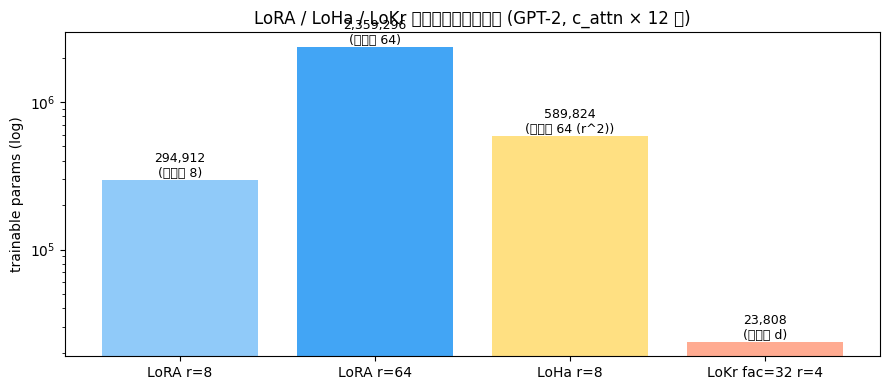


LoHa: 2× 参数 → 8× 等效秩
LoKr: 0.08× 参数 → 满秩 (最高表达力)


In [5]:
methods = [
    ('LoRA r=8',   294912,  '8',  '#90caf9'),
    ('LoRA r=64',  2359296, '64', '#42a5f5'),
    ('LoHa r=8',   589824,  '64 (r^2)', '#ffe082'),
    ('LoKr fac=32 r=4', 23808, 'd', '#ffab91'),
]
names = [m[0] for m in methods]
params = [m[1] for m in methods]
colors = [m[3] for m in methods]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(names, params, color=colors)
for bar, p, m in zip(bars, params, methods):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{p:,}\n(等效秩 {m[2]})', ha='center', va='bottom', fontsize=9)
ax.set_yscale('log')
ax.set_ylabel('trainable params (log)')
ax.set_title('LoRA / LoHa / LoKr 参数量与等效秩对比 (GPT-2, c_attn × 12 层)')
plt.tight_layout()
plt.show()
print('\nLoHa: 2× 参数 → 8× 等效秩')
print('LoKr: 0.08× 参数 → 满秩 (最高表达力)')

## 5. peft 兼容性说明

**peft 的 `LoHaConfig` / `LoKrConfig` 当前不支持 GPT-2 的 `transformers.pytorch_utils.Conv1D`**（仅支持 `nn.Linear`、`nn.Conv1d`、`nn.Conv2d`）。

在 LLaMA、BERT 等使用 `nn.Linear` 的模型上可直接用 peft：

```python
from peft import LoHaConfig, LoKrConfig

loha_cfg = LoHaConfig(r=8, alpha=16, target_modules=['q_proj', 'v_proj'])
lokr_cfg = LoKrConfig(r=4, alpha=4, target_modules=['q_proj', 'v_proj'], decompose_factor=8)
```

在 GPT-2 上要用 peft 的 LoHa/LoKr，需先把 Conv1D 替换成 nn.Linear。本 notebook 用 minimal 实现演示算法。

## 6. 思考题

1. **公式题**：Schur 定理证明思路：在 M_1 ⊙ M_2 = (B_1 A_1) ⊙ (B_2 A_2) 上做 SVD，推出 rank ≤ r²。
2. **公式题**：写出 B ⊗ A 的 (i, j) 元素表达式（用 i_1, i_2, j_1, j_2 索引）。
3. **代码题**：在 `loha_minimal.py` 上加 r-dropout（训练时随机 mask r 中的几个 channel）。
4. **设计题**：为什么 LoKr 在 Stable Diffusion 上比 NLP 更有效？
5. **对比题**：画 LoRA、LoHa、LoKr 在 '参数量 vs 等效秩' 的 Pareto 曲线。
6. **实践题**：调 LoKr 的 factor=24, 48, 96，看参数量与等效秩怎么变化。